<a href="https://colab.research.google.com/github/bernaldiaz/bernaldiaz/blob/main/ecuacion_tercer_orden_3_metodos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Se trata de resolver esta ecuacion por tres metodos $ ax'''​+ax¨+bx˙+cx=sin(t)$

In [1]:
#Definimos el sistema una sola vez
import numpy as np
import matplotlib.pyplot as plt

a = 1.5
b = 2.0
c = 1.0

def rates(t, f):
    x1, x2, x3 = f
    return np.array([
        x2,
        x3,
        np.sin(t) - a*x3 - b*x2 - c*x1
    ])


In [2]:
#Parámetros de integración
h = 0.05
t0 = 0.0
tf = 20.0
N = int((tf - t0)/h)

t = np.linspace(t0, tf, N+1)

# Condiciones iniciales
f0 = np.array([0.0, 0.0, 0.0])


In [3]:
#Método de Euler
f_euler = np.zeros((N+1, 3))
f_euler[0] = f0

for n in range(N):
    f_euler[n+1] = f_euler[n] + h * rates(t[n], f_euler[n])


In [4]:
#Método de Heun (RK2)
f_heun = np.zeros((N+1, 3))
f_heun[0] = f0

for n in range(N):
    k1 = rates(t[n], f_heun[n])
    f_pred = f_heun[n] + h * k1
    k2 = rates(t[n] + h, f_pred)

    f_heun[n+1] = f_heun[n] + (h/2)*(k1 + k2)


In [5]:
# Método Runge–Kutta de orden 4 (RK4)
f_rk4 = np.zeros((N+1, 3))
f_rk4[0] = f0

for n in range(N):
    k1 = rates(t[n], f_rk4[n])
    k2 = rates(t[n] + h/2, f_rk4[n] + h*k1/2)
    k3 = rates(t[n] + h/2, f_rk4[n] + h*k2/2)
    k4 = rates(t[n] + h,   f_rk4[n] + h*k3)

    f_rk4[n+1] = f_rk4[n] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)


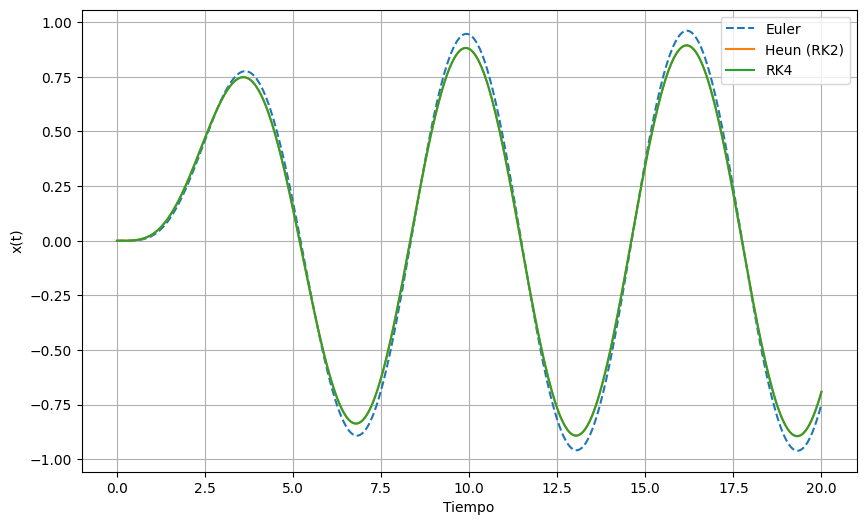

In [6]:
# Comparación gráfica (solo x(t))
plt.figure(figsize=(10,6))
plt.plot(t, f_euler[:,0], label="Euler", linestyle="--")
plt.plot(t, f_heun[:,0], label="Heun (RK2)")
plt.plot(t, f_rk4[:,0], label="RK4")
plt.xlabel("Tiempo")
plt.ylabel("x(t)")
plt.legend()
plt.grid()
plt.show()
